In [2]:
%pip install numpy scipy matplotlib scikit-learn umap-learn h5py

import numpy as np
import scipy
import sklearn
import umap
import matplotlib.pyplot as plt
import os

print("✅ Packages installed successfully.")

Note: you may need to restart the kernel to use updated packages.
✅ Packages installed successfully.


In [3]:
#查看包版本
import scipy.io as sio
from scipy.io import loadmat


print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("UMAP imported successfully")

NumPy version: 1.21.5
SciPy version: 1.7.3
Scikit-learn version: 1.0.2
UMAP imported successfully


In [4]:
# Raman x轴 mat 文件
X_AXIS_PATH = "H:/拉曼-实习/肺癌/xhoriba1134.mat"    #記得改地址

# 读取
axis_mat = loadmat(X_AXIS_PATH)

# 查看变量
print("Variables in x-axis MAT:")

for key, value in axis_mat.items():
    if not key.startswith("__"):
        print(key, type(value), getattr(value, "shape", None))

Variables in x-axis MAT:
xHoriba <class 'numpy.ndarray'> (1, 1134)


In [4]:
raman_axis = axis_mat["x_refer1114"]

# 从 (1, 1134) 转换为 (1134,)
raman_axis = np.squeeze(raman_axis)

print("Raman axis shape:", raman_axis.shape)

print("\nFirst 10 Raman shifts:")
print(raman_axis[:10])

KeyError: 'x_refer1114'

In [13]:
raman_axis = axis_mat["xHoriba"]

# 从 (1, 1134) 转换为 (1134,)
raman_axis = np.squeeze(raman_axis)

print("Raman axis shape:", raman_axis.shape)

print("\nFirst 10 Raman shifts:")
print(raman_axis[:10])

Raman axis shape: (1134,)

First 10 Raman shifts:
[ 0.810777  5.09344   9.37415  13.6529   17.9297   22.2046   26.4797
 30.7506   35.0197   39.2868  ]


In [8]:
MAT_PATH = "H:\拉曼-实习\肺癌/LungCancerImageRaw2/Solid_layer1.mat"
n_rows = 210
n_cols = 210
mat = loadmat(MAT_PATH)

print("Variables in Raman MAT:")

for key, value in mat.items():

    if not key.startswith("__"):

        if isinstance(value, np.ndarray):

            print(
                key,
                value.shape,
                value.dtype
            )

Variables in Raman MAT:
data_struct (1, 1) [('name', 'O'), ('data', 'O'), ('axisscale', 'O'), ('imagesize', 'O'), ('imagedimension_um', 'O')]


In [11]:
ds = mat["data_struct"]

print("data_struct type:", type(ds))
print("data_struct shape:", ds.shape)
print("data_struct fields:", ds.dtype.names)

data_struct type: <class 'numpy.ndarray'>
data_struct shape: (1, 1)
data_struct fields: ('name', 'data', 'axisscale', 'imagesize', 'imagedimension_um')


In [12]:
X = ds["data"][0, 0]

print("X type:", type(X))
print("X shape:", X.shape)

X type: <class 'numpy.ndarray'>
X shape: (44100, 1134)


In [14]:
#验证x是否对齐
print("Raman axis length:", len(raman_axis))
print("Spectrum length:", X.shape[-1])

if len(raman_axis) == X.shape[-1]:
    print("✓ Raman axis matches spectral data.")
else:
    print("✗ Length mismatch!")

Raman axis length: 1134
Spectrum length: 1134
✓ Raman axis matches spectral data.


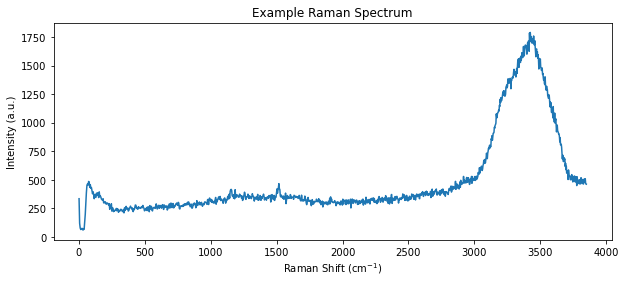

In [16]:
plt.figure(figsize=(10, 4))

plt.plot(
    raman_axis,
    X[0]
)

plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.title("Example Raman Spectrum")

plt.show()

In [17]:
#色阶
from matplotlib.colors import LinearSegmentedColormap

# BrainRegionStaining 风格
brain_colors = [
    (0.00, (0.00, 0.00, 0.00)),   # black
    (0.10, (0.00, 0.00, 0.50)),   # dark blue
    (0.20, (0.00, 0.20, 0.65)),   # deep blue
    (0.30, (0.00, 0.40, 0.80)),   # blue
    (0.40, (0.00, 0.60, 0.90)),   # light blue
    (0.50, (0.00, 0.80, 0.90)),   # cyan-blue
    (0.60, (0.30, 0.60, 0.90)),   # periwinkle
    (0.70, (0.60, 0.40, 0.95)),   # purple
    (0.80, (0.85, 0.30, 0.85)),   # magenta
    (0.90, (1.00, 0.50, 0.75)),   # pink
    (1.00, (1.00, 1.00, 1.00)),   # white
]

brain_cmap = LinearSegmentedColormap.from_list("BrainRegionStaining", brain_colors, N=256)

icolors = [
    (0.00, (0.00, 0.00, 0.00)),   # black
    (0.08, (0.02, 0.04, 0.12)),   # blue black
    (0.18, (0.00, 0.18, 0.45)),   # navy blue
    (0.30, (0.00, 0.50, 0.85)),   # blue cyan
    (0.42, (0.00, 0.85, 0.75)),   # teal
    (0.54, (0.35, 0.95, 0.45)),   # green
    (0.66, (0.65, 0.55, 1.00)),   # soft violet
    (0.78, (0.95, 0.35, 0.85)),   # magenta
    (0.90, (1.00, 0.70, 0.30)),   # orange gold
    (1.00, (1.00, 1.00, 1.00)),   # white
]

icmap = LinearSegmentedColormap.from_list(
    "Balanced_Jump_BlackToWhite",
    icolors,
    N=256
)

In [18]:
print("X shape:", X.shape)
print("raman_axis shape:", raman_axis.shape)

X shape: (44100, 1134)
raman_axis shape: (1134,)


In [19]:
# 去掉 nan / inf
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# 每条光谱减去最小值
X_pre = X - X.min(axis=1, keepdims=True)

# 每条光谱归一化到最大值 = 1
X_pre = X_pre / (X_pre.max(axis=1, keepdims=True) + 1e-12)

print("X_pre shape:", X_pre.shape)

X_pre shape: (44100, 1134)


In [20]:
#PCA-50D不做
#from sklearn.decomposition import PCA
from sklearn.cluster import KMeans



In [21]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.05,
    metric="cosine",
    random_state=42
)

X_umap = reducer.fit_transform(X_pre)

print("X_umap shape:", X_umap.shape)

D:\Users\zhangchangyang\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


X_umap shape: (44100, 2)


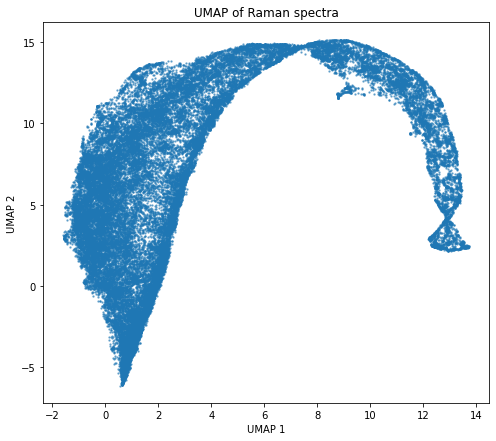

In [22]:
plt.figure(figsize=(8, 7))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=2,
    alpha=0.5
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of Raman spectra")
plt.show()

In [23]:
n_clusters = 60

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_umap)

print("labels shape:", labels.shape)
print("Unique clusters:", np.unique(labels))
print("Number of clusters:", len(np.unique(labels)))

labels shape: (44100,)
Unique clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59]
Number of clusters: 60


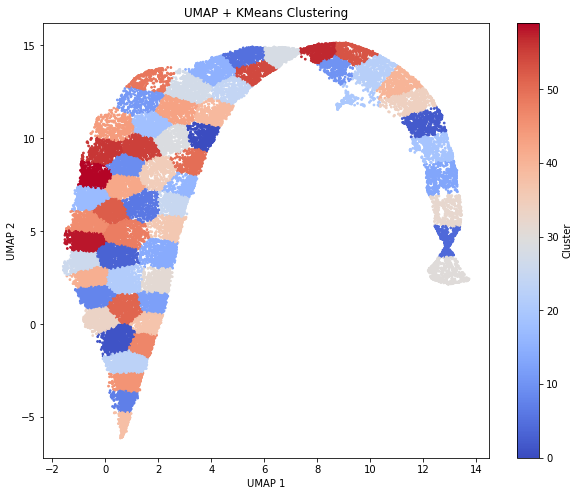

In [24]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    s=3,
    cmap="coolwarm"
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP + KMeans Clustering")
plt.colorbar(sc, label="Cluster")
plt.show()

In [25]:

cluster_map = labels.reshape((n_rows, n_cols),
    order="F")

print("cluster_map shape:", cluster_map.shape)

cluster_map shape: (210, 210)


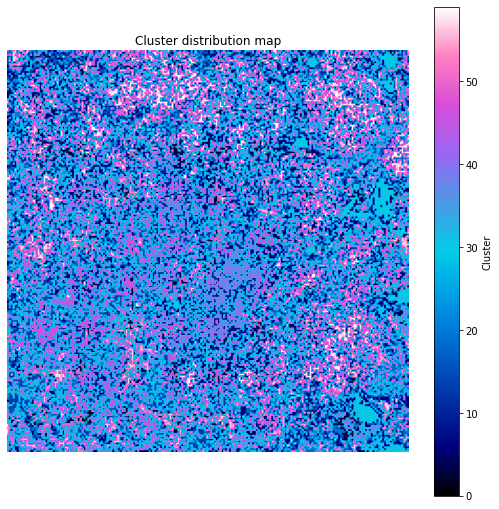

In [26]:
plt.figure(figsize=(9,9 ))
plt.imshow(cluster_map, origin="lower", cmap=brain_cmap)
plt.title("Cluster distribution map")
plt.colorbar(label="Cluster")
plt.axis("off")
plt.show()

In [27]:
cluster_spectra = []

for k in range(n_clusters):
    idx = (labels == k)
    mean_spec = X_pre[idx].mean(axis=0)
    cluster_spectra.append(mean_spec)

cluster_spectra = np.array(cluster_spectra)

print("cluster_spectra shape:", cluster_spectra.shape)

cluster_spectra shape: (60, 1134)


In [28]:
n_clusters = 60

fig, axes = plt.subplots(
    10, 10,
    figsize=(20, 20)
)

axes = axes.ravel()

for k in range(n_clusters):

    binary_map = (cluster_map == k).astype(float)

    axes[k].imshow(
        binary_map,
        origin="lower",
        cmap="gray"
    )

    axes[k].set_title(
        f"Cluster {k}",
        fontsize=8
    )

    axes[k].axis("off")

plt.tight_layout()
plt.show()

(44100,)
(210, 210)


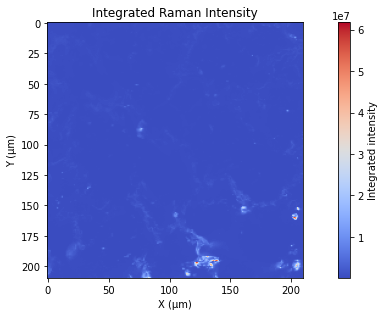

In [29]:
total_intensity = np.sum(X, axis=1)



print(total_intensity.shape)
raw_map = total_intensity.reshape(
    n_cols,
    n_rows
)

print(raw_map.shape)
plt.figure(figsize=(10, 4.5))

plt.imshow(
    raw_map,
    cmap="coolwarm",
    origin="upper",

    aspect="equal"
)

plt.xlabel("X (µm)")
plt.ylabel("Y (µm)")
plt.title("Integrated Raman Intensity")

plt.colorbar(
    label="Integrated intensity"
)

plt.tight_layout()
plt.show()

In [30]:
#uniform算法！要走extreme别跑
endmembers = []

for k in range(n_clusters):

    idx = (labels == k)

    spectra_k = X_pre[idx]

    mean_spectrum = spectra_k.mean(axis=0)

    endmembers.append(mean_spectrum)

endmembers = np.array(endmembers)

print(endmembers.shape)

(60, 1134)


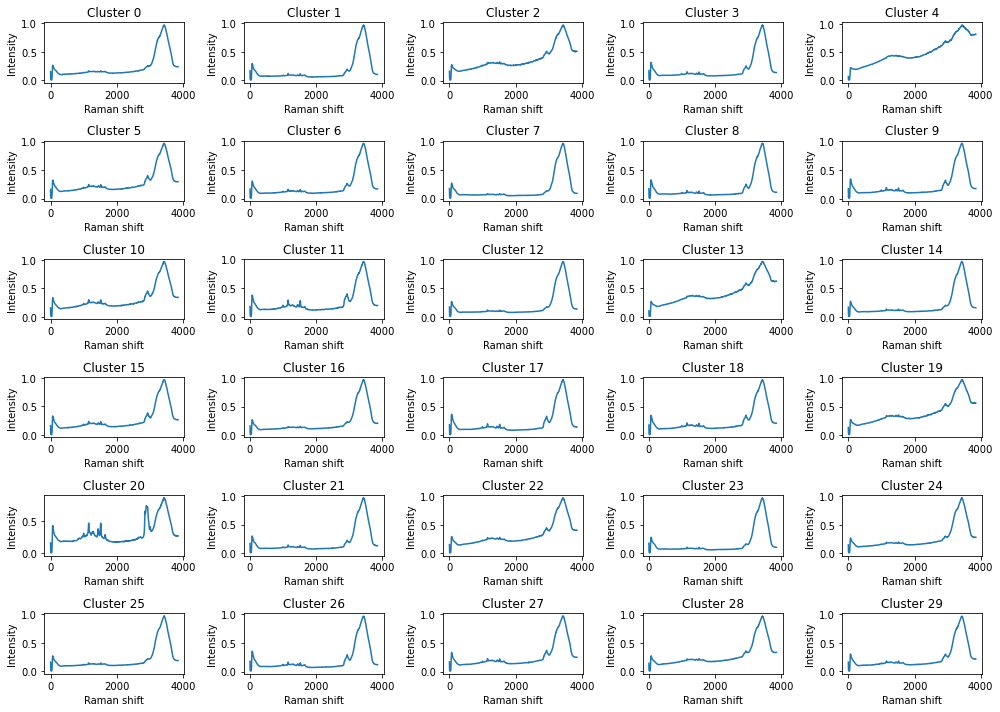

In [31]:
#看16个光谱

fig, axes = plt.subplots(6, 5, figsize=(14, 10))
axes = axes.ravel()

for k in range(30):

    axes[k].plot(
        raman_axis,
        endmembers[k]
    )

    axes[k].set_title(f"Cluster {k}")
    axes[k].set_xlabel("Raman shift")
    axes[k].set_ylabel("Intensity")

plt.tight_layout()
plt.show()

In [36]:
from scipy.io import savemat

save_dir = r"H:/拉曼-实习/肺癌/Solid"
os.makedirs(save_dir, exist_ok=True)

endmember_matrix = np.asarray(endmembers)
axis_values = np.asarray(raman_axis).ravel()

if endmember_matrix.ndim != 2:
    raise ValueError(f"endmembers 应为二维矩阵，实际形状：{endmember_matrix.shape}")

if endmember_matrix.shape[1] != axis_values.size:
    raise ValueError(
        f"光谱有 {endmember_matrix.shape[1]} 个点，"
        f"但 raman_axis 有 {axis_values.size} 个点；请检查是否使用了裁剪后的光谱轴。"
    )

save_path = os.path.join(save_dir, "endmembers_matrix.mat")

savemat(
    save_path,
    {
        "endmembers": endmember_matrix,  # 行 = component，列 = Raman 位移点
    }
)

print("保存完成：", save_path)
print("光谱矩阵形状：", endmember_matrix.shape)


保存完成： H:/拉曼-实习/肺癌/Solid\endmembers_matrix.mat
光谱矩阵形状： (60, 1134)


In [2]:
#逐个保存
for k in range(endmembers.shape[0]):

    intensity = endmembers[k].reshape(1, -1)

    savemat(
        os.path.join(
            save_dir,
            f"component_{k:02d}.mat"
        ),
        {
            "intensity": intensity
        }
    )

print("Done.")

NameError: name 'endmembers' is not defined

In [32]:
#NNLS
from scipy.optimize import nnls

# endmembers:
# (100, 1134)

# NNLS希望矩阵形式是：
# 1134 × 100
E = endmembers.T

print("E shape:", E.shape)

E shape: (1134, 60)


In [33]:
abundance = np.zeros(
    (X_pre.shape[0], n_clusters)
)

for i in range(X_pre.shape[0]):

    coeffs, residual = nnls(
        E,
        X_pre[i]
    )

    abundance[i] = coeffs
    
print(abundance.shape)

(44100, 60)


In [34]:
#相对比例，可以让每个 pixel 的所有 component 加起来等于 1
abundance_relative = abundance / (
    abundance.sum(axis=1, keepdims=True)
    + 1e-12
)


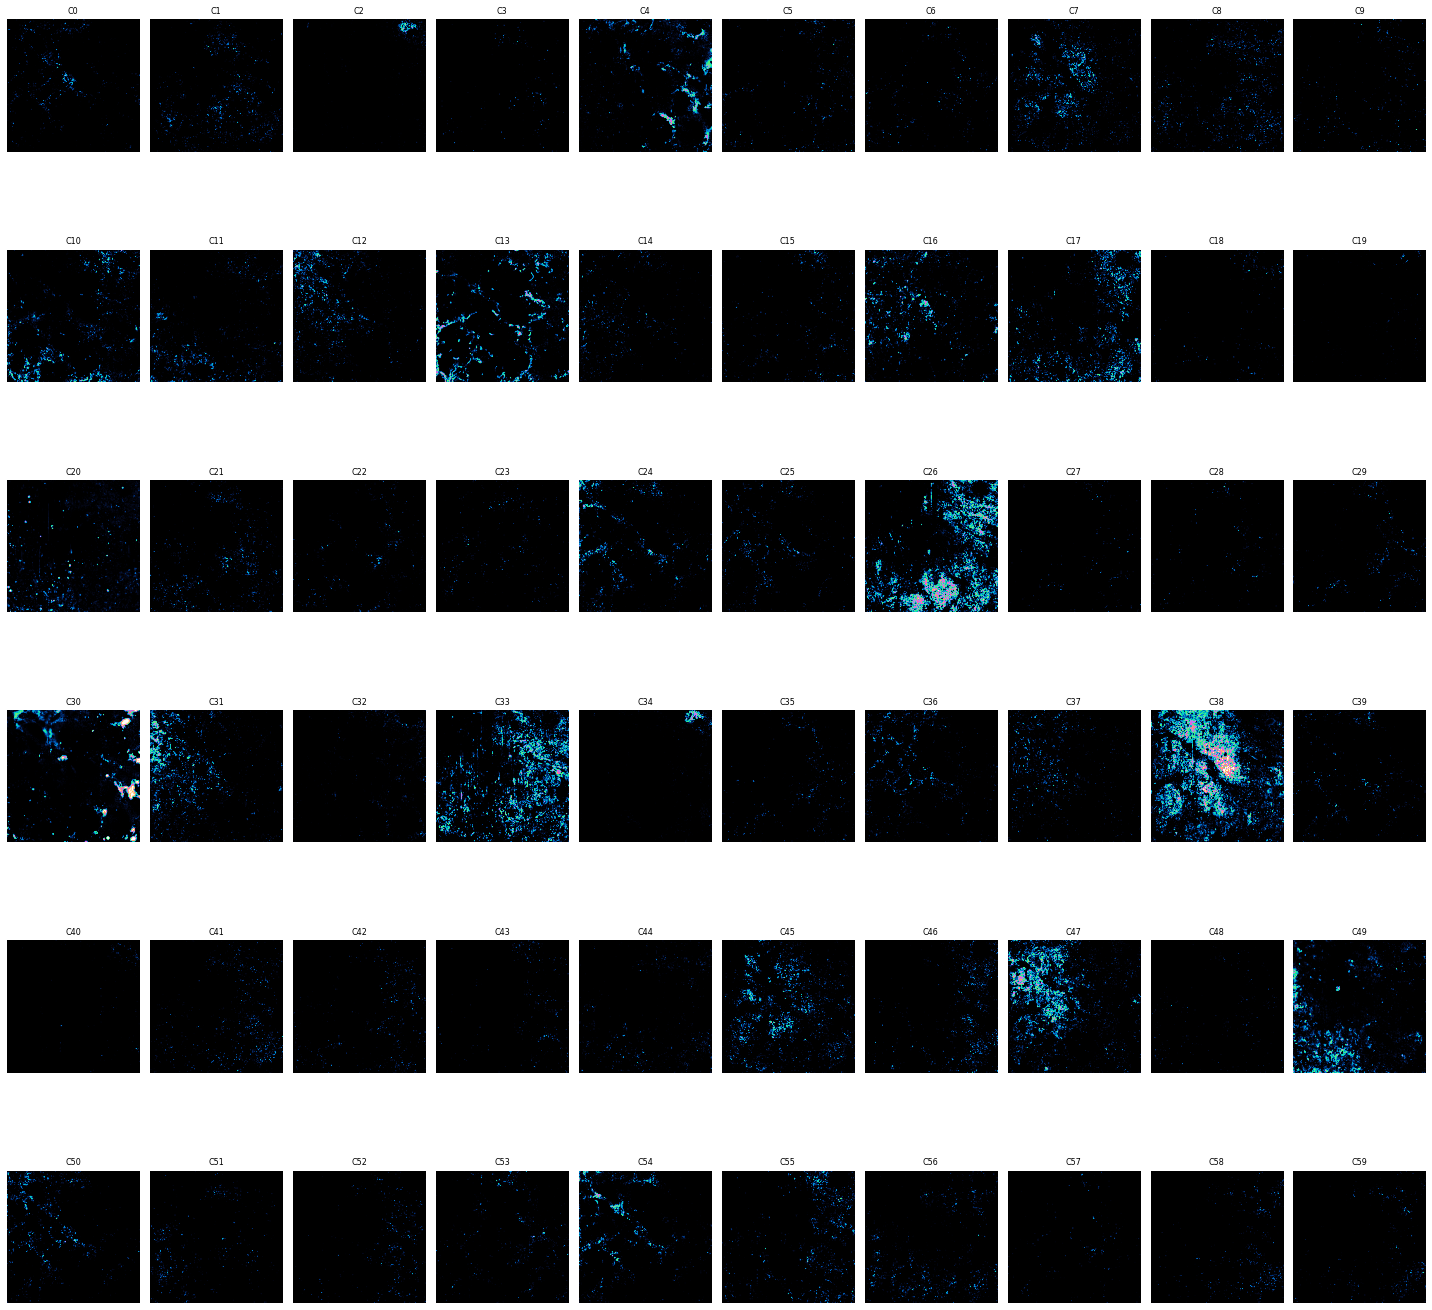

In [35]:
fig, axes = plt.subplots(
    6, 10,
    figsize=(20, 20)
)

axes = axes.ravel()

for k in range(n_clusters):

    abundance_map = abundance_relative[:, k].reshape(
        (n_rows, n_cols),
        order="F"
    )

    axes[k].imshow(
        abundance_map,
        cmap=icmap,
        origin="upper"
    )

    axes[k].set_title(
        f"C{k}",
        fontsize=8
    )

    axes[k].axis("off")

plt.tight_layout()
plt.show()

In [29]:
#每张图输出，不进行全局colorbar

# ========= 参数 =========
n_components = 60
reshape_order = "F"   # 如果你最后确认不是F，就改成正确的
save_dir = "H:/拉曼-实习/肺癌/FZXT_layer1_abundance"

# ========= 创建保存文件夹 =========
os.makedirs(save_dir, exist_ok=True)

# ========= 逐张保存 =========
for k in range(n_components):

    # 恢复第 k 个成分的二维图
    abundance_map = abundance_relative[:, k].reshape(
        (n_rows, n_cols),
        order=reshape_order
    )

    plt.figure(figsize=(6, 8))

    im = plt.imshow(
        abundance_map,
        origin="upper",
        cmap=icmap
    )

    plt.title(f"Component {k} abundance")
    plt.axis("off")

    # 每张图单独的 colorbar
    #plt.colorbar(im, label="Relative abundance")

    # 保存
    save_path = os.path.join(
        save_dir,
        f"component_{k:02d}_abundance.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print(f"Saved {n_components} abundance maps to folder: {save_dir}")

Saved 60 abundance maps to folder: H:/拉曼-实习/肺癌/FZXT_layer1_abundance


In [34]:
#extreme 的处理
#极端
extreme_spectra_robust = []

for k in range(n_clusters):

    idx = np.where(labels == k)[0]

    points_k = X_umap[idx]
    center = kmeans.cluster_centers_[k]

    distances = np.linalg.norm(
        points_k - center,
        axis=1
    )

    # 最远的前5%
    threshold = np.percentile(
        distances,
        95
    )

    extreme_idx_local = np.where(
        distances >= threshold
    )[0]

    extreme_idx_global = idx[
        extreme_idx_local
    ]

    # 对这些“边缘pixel”的真实Raman光谱求平均
    spectrum = X_pre[
        extreme_idx_global
    ].mean(axis=0)

    extreme_spectra_robust.append(
        spectrum
    )

extreme_spectra_robust = np.array(
    extreme_spectra_robust
)

print(
    extreme_spectra_robust.shape
)

(50, 1114)


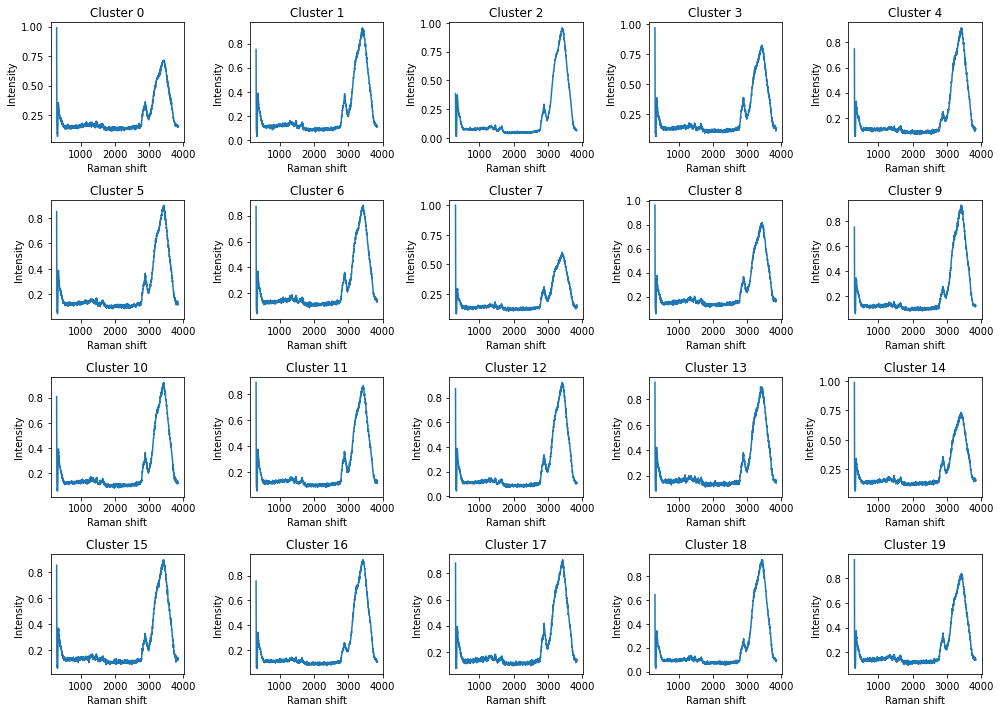

In [35]:
fig, axes = plt.subplots(4, 5, figsize=(14, 10))
axes = axes.ravel()

for k in range(20):

    axes[k].plot(
        raman_axis,
        extreme_spectra_robust[k]
    )

    axes[k].set_title(f"Cluster {k}")
    axes[k].set_xlabel("Raman shift")
    axes[k].set_ylabel("Intensity")

plt.tight_layout()
plt.show()

In [36]:
from scipy.io import savemat

save_dir = "H:/拉曼-实习/肺癌/"
os.makedirs(save_dir, exist_ok=True)

for k in range(extreme_spectra_robust.shape[0]):

    intensity = extreme_spectra_robust[k].reshape(1, -1)

    savemat(
        os.path.join(
            save_dir,
            f"component_{k:02d}.mat"
        ),
        {
            "intensity": intensity
        }
    )

print("Done.")

FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'H:/'

In [37]:
from scipy.optimize import nnls

E2 = extreme_spectra_robust.T
abundance_ex = np.zeros(
    (X_pre.shape[0], n_clusters)
)

for i in range(X_pre.shape[0]):

    coeffs, residual = nnls(
        E2,
        X_pre[i]
    )

    abundance_ex[i] = coeffs
    
print(abundance_ex.shape)

(23405, 50)


In [38]:
abundance_relative2 = abundance_ex / (
    abundance_ex.sum(axis=1, keepdims=True)
    + 1e-12
)

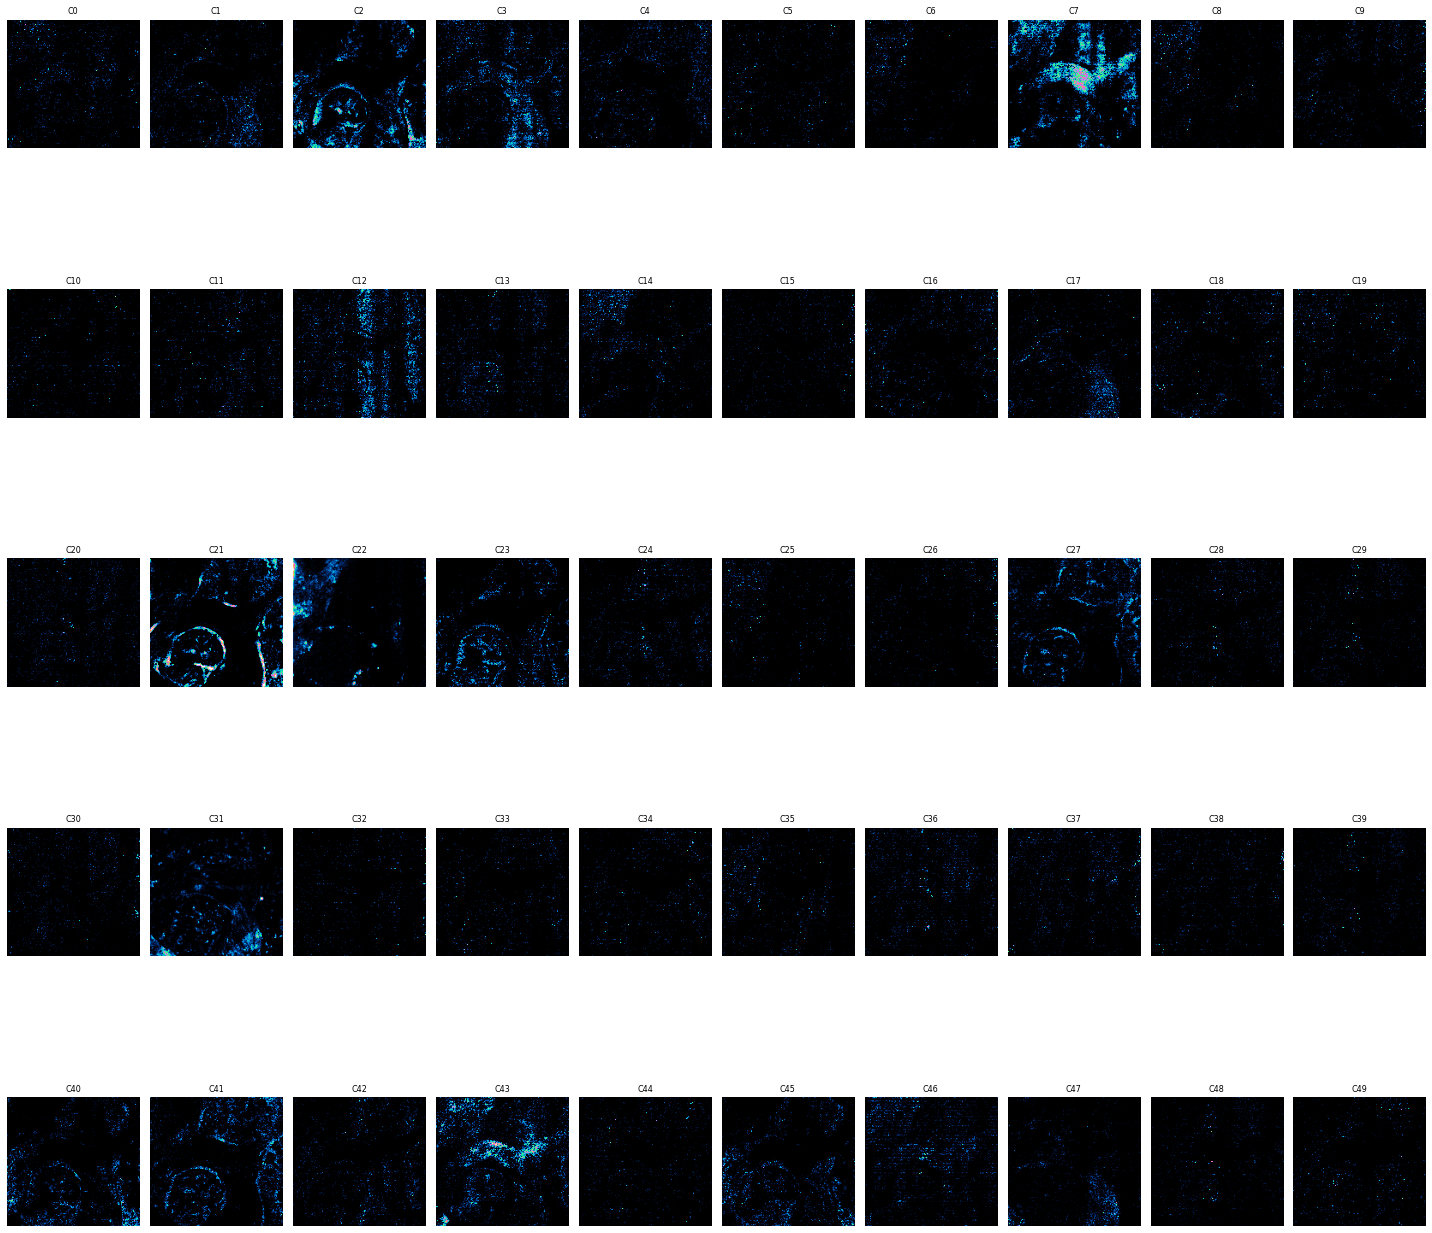

In [39]:
fig, axes = plt.subplots(
    5, 10,
    figsize=(20, 20)
)

axes = axes.ravel()

for k in range(n_clusters):

    abundance_map = abundance_relative2[:, k].reshape(
        (n_rows, n_cols),
        order="F"
    )

    axes[k].imshow(
        abundance_map,
        cmap=icmap,
        origin="upper"
    )

    axes[k].set_title(
        f"C{k}",
        fontsize=8
    )

    axes[k].axis("off")

plt.tight_layout()
plt.show()

In [35]:
#保存

reshape_order = "F"
save_dir = "H:/拉曼-实习/肺癌/"

os.makedirs(save_dir, exist_ok=True)

# 全局最大值，用于统一色标
global_max = abundance_relative2.max()

for k in range(n_components):

    abundance_map = abundance_relative2[:, k].reshape(
        (n_rows, n_cols),
        order=reshape_order
    )

    plt.figure(figsize=(6, 8))

    im = plt.imshow(
        abundance_map,
        origin="upper",
        cmap=icmap,
        vmin=0,
        vmax=global_max
    )

    plt.title(f"Component {k} abundance")
    plt.axis("off")
    plt.colorbar(im, label="Relative abundance")

    save_path = os.path.join(
        save_dir,
        f"component_{k:02d}_abundance.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()
print("Done.")

Done.


In [ ]:
# ============================================================
# 12. 保存相对比例图
# ============================================================

fraction_map_dir = os.path.join(
    output_dir,
    "relative_fraction_maps"
)

os.makedirs(
    fraction_map_dir,
    exist_ok=True
)


for component_idx in range(n_components):

    component_abundance = abundance_relative[
        :,
        component_idx
    ]

    # 使用与正确显示代码完全相同的方式恢复空间坐标
    current_map = component_abundance.reshape(
        (n_rows, n_cols),
        order="F"
    )

    fig, ax = plt.subplots(
        figsize=(6, 8)
    )

    im = ax.imshow(
        current_map,
        cmap=icmap,
        vmin=0,
        vmax=np.percentile(current_map, 99.5),
        origin="upper",
        aspect="equal"
    )

    #colorbar = fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)

    #colorbar.set_label("Relative fraction" )

    #ax.set_title(
        f"Reference component {component_idx + 1}"
    )

    #ax.set_xlabel("X pixel")
    #ax.set_ylabel("Y pixel")

    fig.tight_layout()

    save_path = os.path.join(
        fraction_map_dir,
        f"component_{component_idx + 1:02d}_fraction.png"
    )

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)


print("60张相对比例图已保存。")

In [ ]:
# ============================================================
# 11. 分别绘制并保存60张绝对 abundance map
# ============================================================

absolute_map_dir = os.path.join(
    output_dir,
    "absolute_abundance_maps"
)

os.makedirs(
    absolute_map_dir,
    exist_ok=True
)


for component_idx in range(n_components):

    # 直接从NNLS得到的abundance矩阵中取出当前component
    component_abundance = A_abundance[
        :,
        component_idx
    ]

    # 使用与正确显示代码完全相同的方式恢复空间坐标
    current_map = component_abundance.reshape(
        (n_rows, n_cols),
        order="F"
    )

    fig, ax = plt.subplots(
        figsize=(6, 8)
    )

    im = ax.imshow(
        current_map,
        cmap=icmap,
        origin="upper",
        aspect="equal"
    )

    # 如果需要colorbar，可以取消下面代码的注释
    # colorbar = fig.colorbar(
    #     im,
    #     ax=ax,
    #     fraction=0.046,
    #     pad=0.04
    # )
    #
    # colorbar.set_label(
    #     "Absolute abundance"
    # )

    #ax.set_title(
        f"Reference component {component_idx}"
    )

    #ax.set_xlabel("X pixel")
    #ax.set_ylabel("Y pixel")
   
    fig.tight_layout()

    save_path = os.path.join(
        absolute_map_dir,
        f"component_{component_idx:02d}_abundance.png"
    )

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)


print("60张绝对 abundance map 已保存。")

